# 07 - Modeling: Laptop Price Prediction

This notebook trains and evaluates regression models for laptop price prediction using the fully preprocessed dataset.

Main principles:
- Use one fixed 80/20 train/test split for both targets.
- Never include `price` or `logprice` in the feature matrix.
- Train each model twice: once on `price`, once on `logprice`.
- Convert `logprice` predictions back to the original price scale before the main comparison.
- Save clean artifacts for downstream analysis notebooks.

## 1. Import libraries

Cell này gom các thư viện cần thiết cho toàn bộ quy trình modeling: xử lý dữ liệu, chia tập train/test, huấn luyện mô hình, tính metric, trực quan hóa và lưu artifact. Các warning không quan trọng như `ConvergenceWarning` được ẩn để notebook gọn hơn, nhưng các lỗi train model thật sự vẫn được bắt và in rõ ràng ở phần training.

In [1]:
from __future__ import annotations

import importlib
import pickle
import time
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    max_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 2. Configuration

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Choose the inverse transformation used to convert log predictions back to price.
# Use 'log1p' if logprice = np.log1p(price), or 'log' if logprice = np.log(price).
LOG_TRANSFORM = 'log1p'
CLIP_NEGATIVE_PREDICTIONS = True

PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'laptop_processed_level.csv'

ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'modeling_level'
METRICS_DIR = ARTIFACT_DIR / 'metrics'
PREDICTIONS_DIR = ARTIFACT_DIR / 'predictions'
PLOTS_DIR = PROJECT_ROOT / "reports" / "figures" / "modeling_level"
MODELS_DIR = ARTIFACT_DIR / 'models'
FEATURE_IMPORTANCE_DIR = ARTIFACT_DIR / 'feature_importance'

for directory in [METRICS_DIR, PREDICTIONS_DIR, PLOTS_DIR, MODELS_DIR, FEATURE_IMPORTANCE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_NAME_FOR_FILE = {
    'Linear Regression': 'LinearRegression',
    'Ridge': 'Ridge',
    'Lasso': 'Lasso',
    'ElasticNet': 'ElasticNet',
    'Random Forest': 'RandomForest',
    'Extra Trees': 'ExtraTrees',
    'XGBoost': 'XGBoost',
    'LightGBM': 'LightGBM',
    'CatBoost': 'CatBoost',
}

print(f'Data path: {DATA_PATH}')
print(f'Artifacts path: {ARTIFACT_DIR}')

Data path: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_level.csv
Artifacts path: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level


## 3. Load preprocessed data

Dữ liệu đầu vào được giả định là bản đã preprocessing hoàn chỉnh, vì vậy notebook không làm lại EDA hay feature engineering. Hàm `standardize_target_columns` chỉ chuẩn hóa tên target về `price` và `logprice`; với file hiện tại, hai cột gốc là `target_price` và `log_target_price`, nên bước này giúp notebook vừa đúng yêu cầu modeling vừa chạy được với schema thực tế.

In [3]:
df = pd.read_csv(DATA_PATH)

required_targets = {'target_price', 'log_target_price'}
missing_targets = required_targets.difference(df.columns)
if missing_targets:
    raise ValueError(f'Missing required target columns: {sorted(missing_targets)}')

print(f'Dataset shape: {df.shape}')
display(df.head())
display(df[['target_price', 'log_target_price']].describe())

Dataset shape: (7208, 77)


,brand_is_rare,model_is_rare,ram_missing,storage_missing,screen_missing,target_price,log_target_price,no_info_brand,no_info_model,no_info_cpu_brand,no_info_cpu_tier,no_info_gpu,ram_level,storage_level,screen_size_level,storage_ssd,storage_hdd,no_info_storage,condition_score,warranty_encoded,cpu_tier_encoded,brand_ASUS,brand_Acer,brand_Apple,brand_Dell,brand_Gigabyte,brand_HP,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Other,brand_Sony,brand_Toshiba,model_Aspire,model_Elitebook,model_Elitebook 800,model_Gaming Thin GF,model_IdeaPad,model_Inspiron,model_Latitude,model_Latitude 14 7000,model_Latitude E Series,model_Legion,model_Legion 5,model_MacBook Air,model_MacBook Air M1,model_MacBook Air M2,model_MacBook Pro,model_MacBook Pro M1,model_MacBook Pro M2,model_Macbook air m4,model_Nitro 5,model_Other,model_Pavilion 15,model_Precision,model_ProBook,model_ROG Strix,model_TUF Gaming,model_TUF Gaming F15,model_ThinkPad,model_ThinkPad X1 Carbon,model_Vivobook 15,model_Vostro,model_X Series,model_XPS 13,cpu_brand_AMD,cpu_brand_Apple,cpu_brand_Intel,cpu_brand_Microsoft SQ,cpu_brand_Other,cpu_brand_Qualcomm,gpu_tier_ord_filled,gpu_type_Apple SoC,gpu_type_Dedicated,gpu_type_Integrated,gpu_type_Missing_Info
0,0,0,0,0,0,9.9900,2.3970,0,0,0,0,0,4,2,1,1,0,0,2,1,6,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,0,4.5000,1.7047,0,1,0,0,0,3,1,3,1,0,0,2,1,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
2,0,0,0,0,0,3.5000,1.5041,0,1,0,0,0,3,3,1,1,0,0,2,1,6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
3,0,0,0,0,0,37.5000,3.6507,0,1,0,1,0,5,3,1,1,0,0,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
4,0,0,0,0,0,7.9900,2.1961,0,1,1,1,0,4,2,1,1,0,0,2,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0


,target_price,log_target_price
count,"7,208.0000","7,208.0000"
mean,15.0088,2.4494
std,15.4028,0.7924
min,1.0000,0.6931
25%,5.6000,1.8871
50%,10.5000,2.4423
75%,18.9000,2.9907
max,179.4000,5.1952


## 4. Define feature matrix and targets

Đây là bước quan trọng nhất để tránh data leakage. Feature matrix `X` được tạo bằng cách loại bỏ cả `price` và `logprice`, còn hai target được giữ riêng biệt: `y_price` dùng cho mô hình dự đoán giá trực tiếp, `y_logprice` dùng cho mô hình học trên log scale. Notebook cũng kiểm tra lại rằng không còn target nào nằm trong `X` trước khi train.

In [4]:
TARGET_COLUMNS = ['target_price', 'log_target_price']

X = df.drop(columns=TARGET_COLUMNS)
y_price = df['target_price']
y_logprice = df['log_target_price']

leakage_columns = {'target_price', 'log_target_price'}.intersection(X.columns)
if leakage_columns:
    raise ValueError(f'Data leakage detected in X: {sorted(leakage_columns)}')

non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    raise ValueError(
        'All features should be numeric after preprocessing. '
        f'Non-numeric columns found: {non_numeric_columns}'
    )

feature_names = X.columns.tolist()

print(f'Feature matrix shape: {X.shape}')
print(f'Price target shape: {y_price.shape}')
print(f'Logprice target shape: {y_logprice.shape}')

Feature matrix shape: (7208, 75)
Price target shape: (7208,)
Logprice target shape: (7208,)


## 5. Train/test split 80/20

Cùng một lệnh `train_test_split` được dùng đồng thời cho `X`, `y_price` và `y_logprice`. Cách này đảm bảo mọi model, dù train trên target nào, đều được so sánh trên đúng cùng tập test và cùng các sample, giúp kết quả giữa `price` và `logprice` công bằng hơn.

In [5]:
X_train, X_test, y_price_train, y_price_test, y_log_train, y_log_test = train_test_split(
    X,
    y_price,
    y_logprice,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_price_train: {y_price_train.shape}')
print(f'y_log_train  : {y_log_train.shape}')
print('Same split is used for price and logprice targets.')

X_train: (5766, 75)
X_test : (1442, 75)
y_price_train: (5766,)
y_log_train  : (5766,)
Same split is used for price and logprice targets.


## 6. Define metrics functions

Các metric chính gồm MAE, RMSE, R2, MAPE, Median Absolute Error và Max Error. Với bảng so sánh chính, tất cả metric luôn được tính trên cùng đơn vị là giá laptop thật (`price scale`), vì đây là đơn vị có ý nghĩa trực tiếp nhất khi báo cáo sai số dự đoán.

In [6]:
def calculate_metrics(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Calculate regression metrics on the same scale for y_true and y_pred."""
    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)

    return {
        'mae': mean_absolute_error(y_true_arr, y_pred_arr),
        'rmse': root_mean_squared_error(y_true_arr, y_pred_arr),
        'r2': r2_score(y_true_arr, y_pred_arr),
        'mape': mean_absolute_percentage_error(y_true_arr, y_pred_arr),
        'median_ae': median_absolute_error(y_true_arr, y_pred_arr),
        'max_error': max_error(y_true_arr, y_pred_arr),
    }

## 7. Define inverse log transform function

Mô hình train bằng `logprice` sẽ predict ra giá trị trên log scale. Trước khi so sánh với `y_price_test`, prediction này bắt buộc được inverse về price scale bằng `np.expm1` hoặc `np.exp` tùy cấu hình. Notebook cũng clip prediction âm về 0 để tránh các giá trị không hợp lý sau inverse transform.

In [7]:
def inverse_log_transform(y_pred_log: np.ndarray, method: str = 'log1p') -> np.ndarray:
    """Convert log-scale predictions back to price scale."""
    y_pred_log = np.asarray(y_pred_log, dtype=float)

    if method == 'log1p':
        y_pred_price = np.expm1(y_pred_log)
    elif method == 'log':
        y_pred_price = np.exp(y_pred_log)
    else:
        raise ValueError("method must be either 'log1p' or 'log'")

    if CLIP_NEGATIVE_PREDICTIONS:
        y_pred_price = np.maximum(y_pred_price, 0)

    return y_pred_price


def infer_log_transform(y_price_values: pd.Series, y_log_values: pd.Series) -> pd.DataFrame:
    """Quick diagnostic comparing configured transform to observed target values."""
    price = np.asarray(y_price_values, dtype=float)
    log_values = np.asarray(y_log_values, dtype=float)
    diagnostics = pd.DataFrame(
        {
            'method': ['log1p', 'log'],
            'mean_abs_difference': [
                np.mean(np.abs(np.log1p(price) - log_values)),
                np.mean(np.abs(np.log(price) - log_values)),
            ],
        }
    ).sort_values('mean_abs_difference')
    return diagnostics

log_transform_diagnostics = infer_log_transform(y_price, y_logprice)
display(log_transform_diagnostics)
print(f'Configured LOG_TRANSFORM = {LOG_TRANSFORM!r}')

,method,mean_abs_difference
0,log1p,0.0000
1,log,0.1298


Configured LOG_TRANSFORM = 'log1p'


## 8. Define models

Danh sách model được định nghĩa theo một cấu trúc thống nhất gồm tên model, loại model và estimator. Các model tuyến tính được đặt trong pipeline có `StandardScaler` vì chúng nhạy với thang đo feature; các tree-based model không cần scaler. XGBoost, LightGBM và CatBoost là optional: nếu môi trường chưa cài, notebook chỉ cảnh báo và bỏ qua thay vì dừng toàn bộ quy trình.

In [8]:
def optional_import(module_name: str, class_name: str) -> Optional[Any]:
    """Import optional model classes without crashing the notebook."""
    try:
        module = importlib.import_module(module_name)
        return getattr(module, class_name)
    except Exception as exc:
        print(f'Warning: {class_name} is not available and will be skipped. Details: {exc}')
        return None


def make_linear_pipeline(estimator: Any) -> Pipeline:
    return Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('model', estimator),
        ]
    )


def define_models() -> List[Dict[str, Any]]:
    models: List[Dict[str, Any]] = [
        {
            'model_name': 'Linear Regression',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(LinearRegression()),
        },
        {
            'model_name': 'Ridge',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(Ridge(alpha=1.0)),
        },
        {
            'model_name': 'Lasso',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(Lasso(alpha=0.001, max_iter=10000)),
        },
        {
            'model_name': 'ElasticNet',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)),
        },
        {
            'model_name': 'Random Forest',
            'model_type': 'tree_ensemble',
            'estimator': RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },
        {
            'model_name': 'Extra Trees',
            'model_type': 'tree_ensemble',
            'estimator': ExtraTreesRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },
    ]

    XGBRegressor = optional_import('xgboost', 'XGBRegressor')
    if XGBRegressor is not None:
        models.append(
            {
                'model_name': 'XGBoost',
                'model_type': 'gradient_boosting',
                'estimator': XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=RANDOM_STATE,
                    objective='reg:squarederror',
                    n_jobs=-1,
                ),
            }
        )

    LGBMRegressor = optional_import('lightgbm', 'LGBMRegressor')
    if LGBMRegressor is not None:
        models.append(
            {
                'model_name': 'LightGBM',
                'model_type': 'gradient_boosting',
                'estimator': LGBMRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            }
        )

    CatBoostRegressor = optional_import('catboost', 'CatBoostRegressor')
    if CatBoostRegressor is not None:
        models.append(
            {
                'model_name': 'CatBoost',
                'model_type': 'gradient_boosting',
                'estimator': CatBoostRegressor(
                    iterations=500,
                    learning_rate=0.05,
                    depth=6,
                    random_seed=RANDOM_STATE,
                    verbose=0,
                    allow_writing_files=False,
                ),
            }
        )

    return models


model_specs = define_models()
print(f'Number of models to train: {len(model_specs)}')
print([spec['model_name'] for spec in model_specs])

Number of models to train: 8
['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'Random Forest', 'Extra Trees', 'LightGBM', 'CatBoost']


## Helper functions for training, persistence, plots, and feature importance

Các hàm helper giúp notebook ngắn gọn và dễ bảo trì hơn. Một hàm training duy nhất được dùng cho cả hai target, trong đó logic khác biệt nằm ở bước hậu xử lý prediction: target `price` được dùng trực tiếp, còn target `logprice` được inverse về price scale trước khi tính metric và lưu prediction.

In [9]:
def safe_filename(model_name: str, target_used: str) -> str:
    base_name = MODEL_NAME_FOR_FILE.get(model_name, model_name.replace(' ', ''))
    return f'{base_name}_{target_used}'


def save_model(model: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, path)


def train_and_evaluate_model(
    model: Any,
    model_name: str,
    model_type: str,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test_price: pd.Series,
    target_used: str,
    y_test_log: Optional[pd.Series] = None,
) -> Tuple[Any, Dict[str, Any], np.ndarray, Optional[Dict[str, float]]]:
    """Fit a model and evaluate predictions on price scale."""
    estimator = clone(model)

    start_train = time.perf_counter()
    estimator.fit(X_train, y_train)
    train_time_sec = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    raw_pred = estimator.predict(X_test)
    predict_time_sec = time.perf_counter() - start_pred

    log_scale_metrics = None
    if target_used == 'log_target_price':
        y_pred_price = inverse_log_transform(raw_pred, method=LOG_TRANSFORM)
        if y_test_log is not None:
            log_scale_metrics = calculate_metrics(y_test_log, raw_pred)
    elif target_used == 'target_price':
        y_pred_price = np.asarray(raw_pred, dtype=float)
        if CLIP_NEGATIVE_PREDICTIONS:
            y_pred_price = np.maximum(y_pred_price, 0)
    else:
        raise ValueError("target_used must be 'target_price' or 'log_target_price'")

    metrics = calculate_metrics(y_test_price, y_pred_price)
    metrics.update(
        {
            'model_name': model_name,
            'model_type': model_type,
            'target_used': target_used,
            'evaluation_scale': 'target_price',
            'train_time_sec': train_time_sec,
            'predict_time_sec': predict_time_sec,
        }
    )

    return estimator, metrics, y_pred_price, log_scale_metrics


def plot_metric_comparison(metrics_df: pd.DataFrame, metric_name: str) -> None:
    metric_label = metric_name.upper() if metric_name in ['mae', 'rmse', 'r2', 'mape'] else metric_name
    plot_df = metrics_df.sort_values(metric_name, ascending=(metric_name != 'r2'))

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=plot_df, x='model_name', y=metric_name, hue='target_used')
    ax.set_title(f'{metric_label} Comparison by Model and Target')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_label)
    ax.tick_params(axis='x', rotation=35)
    plt.legend(title='Target used')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'{metric_name}_comparison.png', dpi=160, bbox_inches='tight')
    plt.show()


def plot_actual_vs_predicted(y_true: pd.Series, y_pred: np.ndarray, model_name: str, target_used: str) -> None:
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.55, edgecolor=None)
    min_value = min(np.min(y_true), np.min(y_pred))
    max_value = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {model_name} ({target_used})')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'actual_vs_predicted_{safe_filename(model_name, target_used)}.png', dpi=160, bbox_inches='tight')
    plt.show()


def plot_residuals(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    target_used: str,
    ax=None,
    save: bool = True
) -> None:
    residuals = np.asarray(y_true) - np.asarray(y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True
    else:
        fig = ax.figure
        show_plot = False

    sns.scatterplot(
        x=y_pred,
        y=residuals,
        alpha=0.55,
        edgecolor=None,
        ax=ax
    )

    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Residual Plot - {model_name} ({target_used})")
    ax.set_xlabel("Predicted Price")
    ax.set_ylabel("Residual: Actual - Predicted")

    if show_plot:
        fig.tight_layout()

        if save:
            fig.savefig(
                PLOTS_DIR / f"residuals_{safe_filename(model_name, target_used)}.png",
                dpi=160,
                bbox_inches="tight"
            )

        plt.show()


def plot_error_distribution(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    target_used: str,
    ax=None,
    save: bool = True
) -> None:
    errors = np.asarray(y_true) - np.asarray(y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True
    else:
        fig = ax.figure
        show_plot = False

    sns.histplot(
        errors,
        kde=True,
        bins=40,
        ax=ax
    )

    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Error Distribution - {model_name} ({target_used})")
    ax.set_xlabel("Prediction Error: Actual - Predicted")
    ax.set_ylabel("Count")

    if show_plot:
        fig.tight_layout()

        if save:
            fig.savefig(
                PLOTS_DIR / f"error_distribution_{safe_filename(model_name, target_used)}.png",
                dpi=160,
                bbox_inches="tight"
            )

        plt.show()

def plot_target_comparison(metrics_df: pd.DataFrame, metric_name: str = 'rmse') -> None:
    comparison_df = metrics_df.pivot(index='model_name', columns='target_used', values=metric_name)
    comparison_df = comparison_df.dropna(how='all').sort_values(by=comparison_df.columns.tolist())

    ax = comparison_df.plot(kind='bar', figsize=(12, 6), width=0.8)
    metric_label = metric_name.upper() if metric_name in ['mae', 'rmse', 'r2', 'mape'] else metric_name
    ax.set_title(f'Price Target vs Logprice Target by Model ({metric_label})')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_label)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Target used')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'target_comparison_{metric_name}.png', dpi=160, bbox_inches='tight')
    plt.show()


def _get_estimator_for_importance(model: Any) -> Any:
    if isinstance(model, Pipeline):
        return model.named_steps.get('model')
    return model


def extract_feature_importance(model: Any, model_name: str, feature_names: List[str]) -> Optional[pd.DataFrame]:
    """Extract feature importances or coefficients when available."""
    fitted_model = _get_estimator_for_importance(model)

    if hasattr(fitted_model, 'feature_importances_'):
        importance = fitted_model.feature_importances_
        importance_type = 'feature_importance'
    elif hasattr(fitted_model, 'coef_'):
        importance = np.ravel(fitted_model.coef_)
        importance_type = 'coefficient'
    else:
        return None

    importance_df = pd.DataFrame(
        {
            'feature': feature_names,
            'importance': importance,
            'abs_importance': np.abs(importance),
            'model_name': model_name,
            'importance_type': importance_type,
        }
    ).sort_values('abs_importance', ascending=False)

    return importance_df

## 9. Train models on `price` and 10. Train models on `logprice`

Vòng lặp training chạy mỗi model hai lần: một lần với target `price`, một lần với target `logprice`. Sau mỗi lần train, notebook lưu model `.pkl`, lưu prediction trên test set, ghi metric chính trên price scale và nếu là log model thì lưu thêm metric phụ trên log scale để tham khảo.

In [10]:
trained_models: Dict[str, Any] = {}
metrics_records: List[Dict[str, Any]] = []
log_scale_metric_records: List[Dict[str, Any]] = []
predictions_df = pd.DataFrame(
    {
        'sample_id': X_test.index,
        'y_true_price': y_price_test.values,
    },
    index=X_test.index,
)

for spec in model_specs:
    model_name = spec['model_name']
    model_type = spec['model_type']
    estimator = spec['estimator']

    for target_used, y_train_current in [('target_price', y_price_train), ('log_target_price', y_log_train)]:
        print(f'Training {model_name} on {target_used}...')
        try:
            fitted_model, metrics, y_pred_price, log_metrics = train_and_evaluate_model(
                model=estimator,
                model_name=model_name,
                model_type=model_type,
                X_train=X_train,
                X_test=X_test,
                y_train=y_train_current,
                y_test_price=y_price_test,
                target_used=target_used,
                y_test_log=y_log_test,
            )
        except Exception as exc:
            print(f'Warning: {model_name} ({target_used}) failed and will be skipped. Details: {exc}')
            continue

        key = f'{model_name}_{target_used}'
        trained_models[key] = fitted_model
        metrics_records.append(metrics)
        predictions_df[f'pred_{safe_filename(model_name, target_used)}'] = y_pred_price

        if log_metrics is not None:
            log_metrics.update(
                {
                    'model_name': model_name,
                    'model_type': model_type,
                    'target_used': target_used,
                    'evaluation_scale': 'log_target_price',
                }
            )
            log_scale_metric_records.append(log_metrics)

        model_path = MODELS_DIR / f'{safe_filename(model_name, target_used)}.pkl'
        save_model(fitted_model, model_path)

print(f'Trained model variants: {len(trained_models)}')

Training Linear Regression on target_price...
Training Linear Regression on log_target_price...
Training Ridge on target_price...
Training Ridge on log_target_price...
Training Lasso on target_price...
Training Lasso on log_target_price...
Training ElasticNet on target_price...
Training ElasticNet on log_target_price...
Training Random Forest on target_price...
Training Random Forest on log_target_price...
Training Extra Trees on target_price...
Training Extra Trees on log_target_price...
Training LightGBM on target_price...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002217 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 175
[LightGBM] [Info] Number of data points in the train set: 5766, number of used features: 72
[LightGBM] [Info] Start training from 

## 11. Evaluate all models on price scale

Bảng `metrics_df` là bảng so sánh chính của notebook. Dù model được train bằng target nào, các cột `mae`, `rmse`, `r2`, `mape`, `median_ae` và `max_error` đều phản ánh hiệu năng trên price scale. Vì vậy có thể đọc trực tiếp bảng này để chọn model phục vụ bài toán dự đoán giá.

In [11]:
metrics_df = pd.DataFrame(metrics_records)
metric_columns = [
    'model_name',
    'model_type',
    'target_used',
    'evaluation_scale',
    'mae',
    'rmse',
    'r2',
    'mape',
    'median_ae',
    'max_error',
    'train_time_sec',
    'predict_time_sec',
]
metrics_df = metrics_df[metric_columns].sort_values('rmse').reset_index(drop=True)

display(metrics_df)

if log_scale_metric_records:
    log_metrics_df = pd.DataFrame(log_scale_metric_records)
    display(log_metrics_df.sort_values('rmse').reset_index(drop=True))
else:
    log_metrics_df = pd.DataFrame()

,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,CatBoost,gradient_boosting,target_price,target_price,3.5232,5.5091,0.8638,0.3338,2.1233,34.8488,6.7037,0.0034
1,CatBoost,gradient_boosting,log_target_price,target_price,3.5104,5.6898,0.8548,0.2976,2.0116,36.6086,2.7241,0.0057
2,LightGBM,gradient_boosting,target_price,target_price,3.5802,5.7955,0.8493,0.3312,2.0342,39.1037,1.2007,0.0139
3,LightGBM,gradient_boosting,log_target_price,target_price,3.4950,5.8081,0.8487,0.2963,1.8476,42.3846,1.6195,0.0182
4,Random Forest,tree_ensemble,log_target_price,target_price,3.6066,5.9864,0.8392,0.3113,1.9254,36.6135,1.8349,0.1616
5,Random Forest,tree_ensemble,target_price,target_price,3.6688,6.0052,0.8382,0.3381,1.9738,38.3213,1.7116,0.1582
6,Extra Trees,tree_ensemble,log_target_price,target_price,3.7978,6.2890,0.8226,0.3309,2.1057,45.0000,2.0182,0.1581
7,Extra Trees,tree_ensemble,target_price,target_price,3.8622,6.3532,0.8189,0.3547,2.1455,45.0000,2.1629,0.1810
8,Ridge,linear,log_target_price,target_price,4.1590,6.5850,0.8055,0.3571,2.4797,48.5077,0.0446,0.0066
9,Linear Regression,linear,log_target_price,target_price,4.1561,6.5929,0.8050,0.3565,2.4827,47.6699,0.3739,0.0031


,mae,rmse,r2,mape,median_ae,max_error,model_name,model_type,target_used,evaluation_scale
0,0.2354,0.3082,0.8469,0.1153,0.1929,2.0551,CatBoost,gradient_boosting,log_target_price,log_target_price
1,0.2328,0.3082,0.8468,0.1144,0.1838,2.0302,LightGBM,gradient_boosting,log_target_price,log_target_price
2,0.2440,0.3260,0.8287,0.1196,0.1910,1.9066,Random Forest,tree_ensemble,log_target_price,log_target_price
3,0.2583,0.3463,0.8067,0.1268,0.2032,1.8837,Extra Trees,tree_ensemble,log_target_price,log_target_price
4,0.2779,0.3555,0.7963,0.1365,0.2295,1.9048,Ridge,linear,log_target_price,log_target_price
5,0.2779,0.3555,0.7962,0.1365,0.2305,1.9045,ElasticNet,linear,log_target_price,log_target_price
6,0.2775,0.3556,0.7962,0.1363,0.2279,1.8953,Linear Regression,linear,log_target_price,log_target_price
7,0.2782,0.3557,0.7960,0.1367,0.2300,1.9060,Lasso,linear,log_target_price,log_target_price


## Model Evaluation Summary

### Overall Performance

Bảng đầu tiên là bảng quan trọng nhất vì tất cả mô hình đều được đánh giá trên cùng một thang đo `target_price`. Với các mô hình được train bằng `log_target_price`, prediction đã được chuyển ngược về giá thật trước khi tính metric. Do `target_price` hiện đã được scale về đơn vị triệu VND, các chỉ số như MAE, RMSE, median absolute error và max error cũng được hiểu theo đơn vị triệu đồng.

Nhìn chung, nhóm mô hình `gradient_boosting` cho kết quả tốt nhất. `CatBoost` train trực tiếp trên `target_price` đạt hiệu năng cao nhất theo RMSE, với RMSE khoảng 5.51 triệu, MAE khoảng 3.54 triệu và R² khoảng 0.864. Kết quả này cho thấy mô hình giải thích được khoảng 86% biến động giá laptop trên tập test.

`CatBoost` train trên `log_target_price` cũng là một mô hình rất cạnh tranh, với MAE khoảng 3.51 triệu, RMSE khoảng 5.71 triệu và R² khoảng 0.854. Mặc dù RMSE cao hơn bản train trực tiếp trên giá, MAE của bản log target thấp hơn nhẹ. Điều này cho thấy log target có thể giúp giảm sai số trung bình tuyệt đối cho phần lớn mẫu, nhưng chưa chắc tốt hơn khi xét các lỗi lớn.

### Target Comparison

Khi so sánh giữa `target_price` và `log_target_price`, kết quả hiện tại cho thấy không có một target nào thắng tuyệt đối ở mọi metric.

Với `CatBoost`, phiên bản train trực tiếp trên `target_price` có RMSE và R² tốt hơn:

- `CatBoost` + `target_price`: RMSE khoảng 5.51, R² khoảng 0.864
- `CatBoost` + `log_target_price`: RMSE khoảng 5.71, R² khoảng 0.854

Tuy nhiên, phiên bản dùng `log_target_price` lại có MAE thấp hơn nhẹ:

- `CatBoost` + `target_price`: MAE khoảng 3.54
- `CatBoost` + `log_target_price`: MAE khoảng 3.51

Điều này cho thấy `log_target_price` có thể giúp mô hình dự đoán ổn hơn cho nhiều mẫu thông thường, nhưng có thể làm tăng một số lỗi lớn, khiến RMSE không tốt bằng bản train trực tiếp trên `target_price`.

Với `LightGBM`, bản train trực tiếp trên `target_price` cũng nhỉnh hơn bản `log_target_price` theo RMSE và R²:

- `LightGBM` + `target_price`: RMSE khoảng 5.78, R² khoảng 0.850
- `LightGBM` + `log_target_price`: RMSE khoảng 5.83, R² khoảng 0.848

Ngược lại, với `Random Forest` và `Extra Trees`, `log_target_price` cho kết quả tốt hơn so với `target_price`. Vì vậy, log-transform vẫn có ích với một số model, nhưng không phải lúc nào cũng là lựa chọn tốt nhất.

### Model Family Comparison

Các mô hình tree-based ensemble, đặc biệt là `CatBoost`, `LightGBM`, `Random Forest` và `Extra Trees`, vượt trội hơn nhóm linear models.

Nhóm boosting đứng đầu bảng với kết quả như sau:

- `CatBoost` + `target_price`: RMSE khoảng 5.51, R² khoảng 0.864
- `CatBoost` + `log_target_price`: RMSE khoảng 5.71, R² khoảng 0.854
- `LightGBM` + `target_price`: RMSE khoảng 5.78, R² khoảng 0.850
- `LightGBM` + `log_target_price`: RMSE khoảng 5.83, R² khoảng 0.848

Trong khi đó, nhóm linear models có hiệu năng thấp hơn rõ rệt. Các mô hình linear train trên `log_target_price` đạt RMSE khoảng 6.57–6.60 và R² khoảng 0.805–0.806. Các mô hình linear train trực tiếp trên `target_price` còn thấp hơn, với RMSE khoảng 7.23–7.25 và R² khoảng 0.764–0.766.

Điều này cho thấy bài toán dự đoán giá laptop có quan hệ phi tuyến khá rõ. Giá laptop không chỉ phụ thuộc tuyến tính vào từng feature riêng lẻ, mà còn phụ thuộc vào interaction giữa nhiều đặc trưng như brand, model, CPU tier, GPU tier, RAM, storage, screen size, condition và warranty.

### Linear Models

Một điểm đáng chú ý là sau khi scale `target_price` về triệu và tính lại `log_target_price`, nhóm linear models train trên `log_target_price` đã ổn định hơn nhiều. Không còn hiện tượng R² âm như trước.

Hiện tại, các linear models dùng `log_target_price` đạt R² khoảng 0.805–0.806, tốt hơn đáng kể so với khi dùng trực tiếp `target_price`, chỉ đạt khoảng 0.764–0.766.

Ví dụ:

- `Ridge` + `log_target_price`: RMSE khoảng 6.57, R² khoảng 0.806
- `Ridge` + `target_price`: RMSE khoảng 7.23, R² khoảng 0.766

Điều này cho thấy log-transform có lợi rõ ràng cho linear models, vì nó làm phân phối target bớt lệch và giảm ảnh hưởng của các giá trị giá cao.

Tuy nhiên, dù đã cải thiện, linear models vẫn kém hơn nhóm tree-based models. Do đó, nhóm này phù hợp để làm baseline hoặc mô hình dễ giải thích, nhưng chưa phải lựa chọn tốt nhất nếu mục tiêu là tối ưu performance.

### Log Scale Evaluation

Bảng thứ hai đánh giá riêng các mô hình được train trên `log_target_price` và tính metric trực tiếp trên log scale. Trên thang đo này, `CatBoost` vẫn là mô hình tốt nhất, với RMSE khoảng 0.309 và R² khoảng 0.846. `LightGBM` đứng rất sát phía sau, với RMSE khoảng 0.310 và R² khoảng 0.845.

Khoảng cách giữa `CatBoost` và `LightGBM` trên log scale là rất nhỏ. Điều này cho thấy cả hai mô hình đều học tốt cấu trúc tương đối của giá, tức là dự đoán khá ổn theo tỷ lệ thay đổi giá chứ không chỉ theo sai số tuyệt đối trên giá gốc.

Nhóm linear models trên log scale cũng không quá tệ, với R² khoảng 0.801–0.803. Điều này khớp với bảng đầu tiên: linear models học `log_target_price` khá ổn, nhưng khi chuyển ngược về giá thật thì vẫn thua các mô hình tree-based.

### Error Pattern

Các mô hình tốt nhất có MAE khoảng 3.5 triệu, nghĩa là trung bình dự đoán lệch khoảng 3.5 triệu đồng. Median absolute error của nhóm top models nằm quanh 1.8–2.1 triệu, thấp hơn MAE khá nhiều. Điều này cho thấy phần lớn dự đoán có lỗi vừa phải, nhưng vẫn tồn tại một số mẫu có lỗi lớn kéo MAE và RMSE lên.

`max_error` của nhóm top models nằm trong khoảng 33–44 triệu:

- `CatBoost` + `target_price`: max error khoảng 33.83 triệu
- `CatBoost` + `log_target_price`: max error khoảng 37.79 triệu
- `LightGBM` + `target_price`: max error khoảng 37.57 triệu
- `LightGBM` + `log_target_price`: max error khoảng 43.55 triệu

Vì vậy, bước tiếp theo nên phân tích các dòng có error lớn nhất để xem chúng thuộc nhóm nào: laptop gaming cao cấp, MacBook, workstation, máy quá cũ hoặc quá mới, cấu hình hiếm, hoặc dữ liệu giá bất thường.

### Training Time

Thời gian train nhìn chung đều chấp nhận được. `CatBoost` đạt performance tốt nhất và thời gian train chỉ khoảng 2.9 giây, rất phù hợp để tiếp tục tuning. `LightGBM` có thời gian train dao động khoảng 2.2–4.9 giây, cũng là một ứng viên mạnh.

Các linear models train rất nhanh, nhưng hiệu năng thấp hơn đáng kể. Với kích thước dữ liệu hiện tại, nên ưu tiên performance hơn training time, vì thời gian train của các model tốt nhất vẫn rất nhỏ.

### Key Takeaways

`CatBoost` train trực tiếp trên `target_price` hiện là mô hình tốt nhất nếu ưu tiên RMSE và R² trên thang giá thật. Đây là lựa chọn baseline chính nên giữ lại cho bước tuning tiếp theo.

`CatBoost` train trên `log_target_price` có MAE tốt hơn nhẹ, nên cũng đáng giữ lại để so sánh thêm, đặc biệt nếu mục tiêu là giảm lỗi trung bình cho đa số mẫu.

`LightGBM` là ứng viên mạnh thứ hai, có performance gần với `CatBoost` và có thể cải thiện thêm bằng hyperparameter tuning.

Nhóm linear models đã không còn R² âm sau khi scale target về triệu và tính lại log, nhưng vẫn kém hơn tree-based ensemble. Chúng nên được giữ làm baseline giải thích, không nên chọn làm model chính.

Tóm lại, hướng tiếp theo nên là giữ `CatBoost` + `target_price` làm baseline chính, giữ thêm `CatBoost` + `log_target_price` để so sánh theo MAE, tiếp tục tune `CatBoost` và `LightGBM`, đồng thời phân tích các mẫu có error lớn nhất theo brand, condition, price range và GPU type.

## 12. Save metrics

Metrics được lưu thành CSV để các notebook phân tích tiếp theo có thể đọc lại mà không cần train lại model. File `model_metrics.csv` là artifact chính; file `log_scale_model_metrics.csv` chỉ là metric phụ cho nhóm model train bằng `logprice`.

In [12]:
metrics_path = METRICS_DIR / 'model_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Saved main metrics to: {metrics_path}')

if not log_metrics_df.empty:
    log_metrics_path = METRICS_DIR / 'log_scale_model_metrics.csv'
    log_metrics_df.to_csv(log_metrics_path, index=False)
    print(f'Saved optional log-scale metrics to: {log_metrics_path}')

Saved main metrics to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\metrics\model_metrics.csv
Saved optional log-scale metrics to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\metrics\log_scale_model_metrics.csv


## 13. Save predictions

File prediction giữ `sample_id`, giá thật và prediction của từng biến thể model. Cấu trúc wide-format này tiện cho các phân tích sau như residual analysis, so sánh từng sample, tìm nhóm laptop có sai số lớn, hoặc tạo ensemble từ nhiều model.

In [13]:
predictions_path = PREDICTIONS_DIR / 'test_predictions.csv'
predictions_df.reset_index(drop=True).to_csv(predictions_path, index=False)
print(f'Saved test predictions to: {predictions_path}')
display(predictions_df.head())

Saved test predictions to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\predictions\test_predictions.csv


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
308,308,9.0000,11.2195,9.4608,11.2485,9.3686,11.2488,9.4181,11.2571,9.3844,7.6981,7.5190,6.5000,6.5000,8.9249,8.5919,9.8751,8.9897
381,381,10.5000,12.6570,8.0575,12.1373,7.9609,12.1410,8.0188,12.1293,8.0003,9.0233,8.8219,9.0997,8.8671,8.9106,8.0921,8.8985,8.4341
1839,1839,2.0000,2.6961,4.4015,2.7663,4.4523,2.7632,4.4485,2.7548,4.4538,2.6361,2.5504,2.1000,2.1000,3.7901,3.4072,3.9191,3.4267
3438,3438,11.5000,15.2742,14.6671,14.3025,14.2411,14.3165,14.0073,14.3146,14.1210,12.8945,12.6684,12.8956,12.6720,13.6136,13.7286,13.1253,13.1830
251,251,9.2000,10.2039,8.8312,10.7768,8.9380,10.7695,8.8652,10.8070,8.8824,8.9856,6.9342,10.9787,9.2191,8.5798,7.1566,8.5532,6.9602


## 14. Save trained models

Mỗi model đã train được lưu riêng theo tên rõ ràng gồm model name và target đã dùng. Điều này giúp load lại đúng biến thể model khi cần inference hoặc phân tích feature importance mà không phải chạy lại notebook.

In [14]:
model_files = sorted(MODELS_DIR.glob('*.pkl'))
print(f'Saved {len(model_files)} model files to: {MODELS_DIR}')
for path in model_files:
    print(path.name)

Saved 16 model files to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\models
CatBoost_log_target_price.pkl
CatBoost_target_price.pkl
ElasticNet_log_target_price.pkl
ElasticNet_target_price.pkl
ExtraTrees_log_target_price.pkl
ExtraTrees_target_price.pkl
Lasso_log_target_price.pkl
Lasso_target_price.pkl
LightGBM_log_target_price.pkl
LightGBM_target_price.pkl
LinearRegression_log_target_price.pkl
LinearRegression_target_price.pkl
RandomForest_log_target_price.pkl
RandomForest_target_price.pkl
Ridge_log_target_price.pkl
Ridge_target_price.pkl


## 15. Generate comparison plots

Các biểu đồ so sánh MAE, RMSE và R2 giúp nhìn nhanh trade-off giữa model và target. Biểu đồ so sánh `price` vs `logprice` theo từng model đặc biệt hữu ích để trả lời câu hỏi: cùng một thuật toán, học trên target nào tốt hơn khi đánh giá trên đơn vị giá thật?

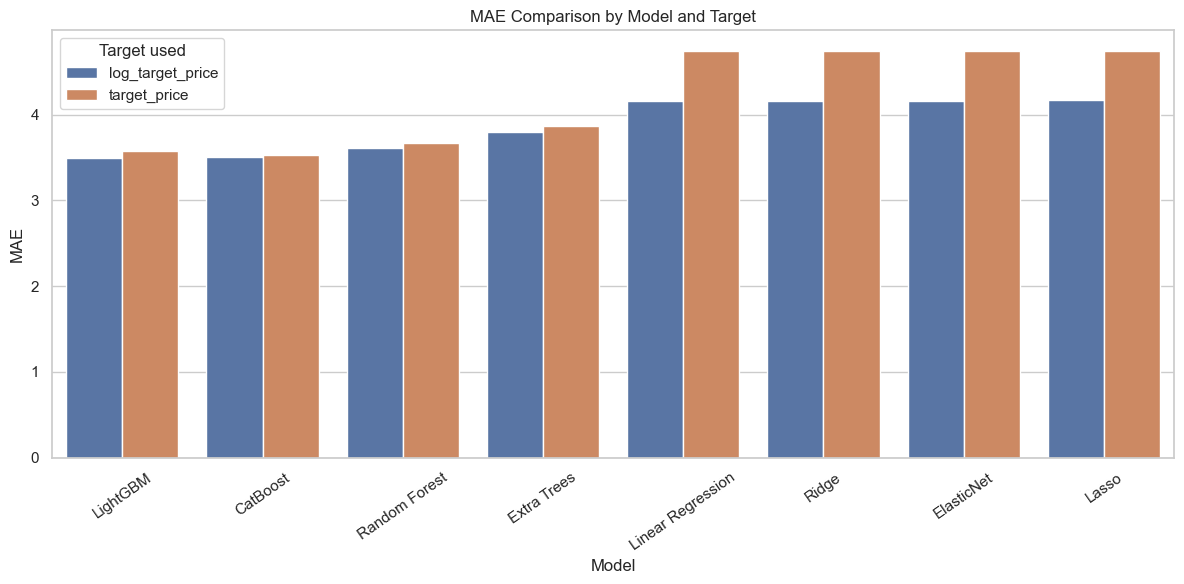

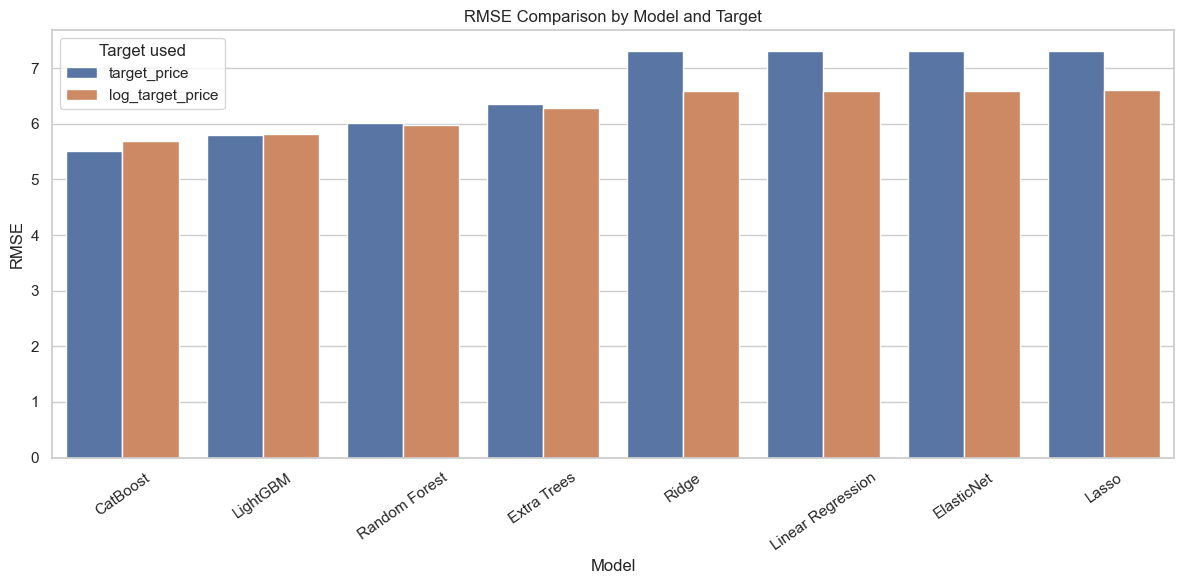

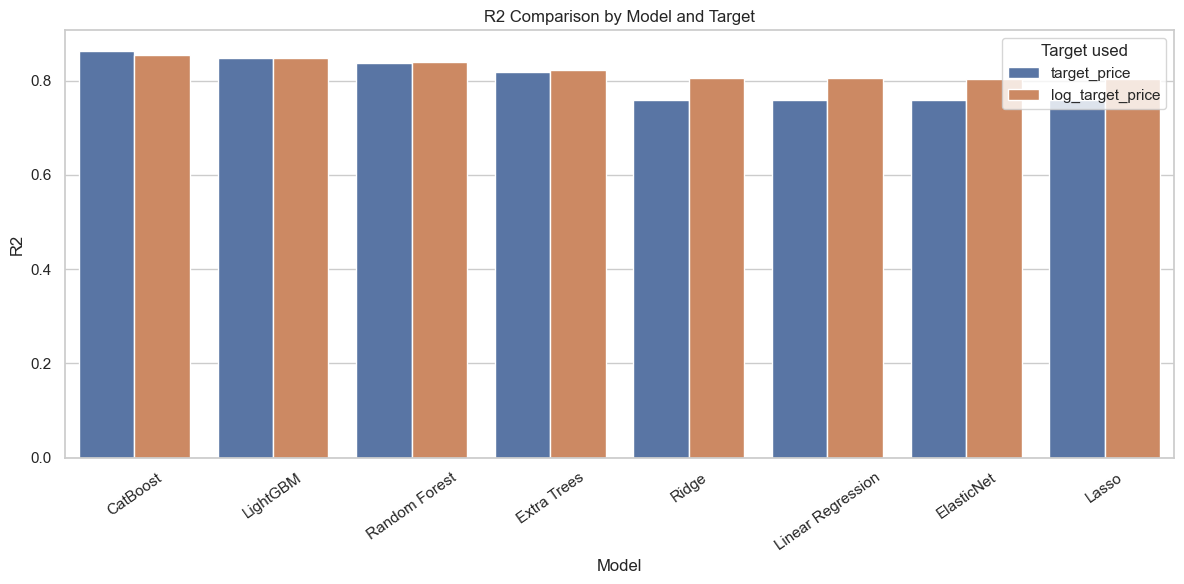

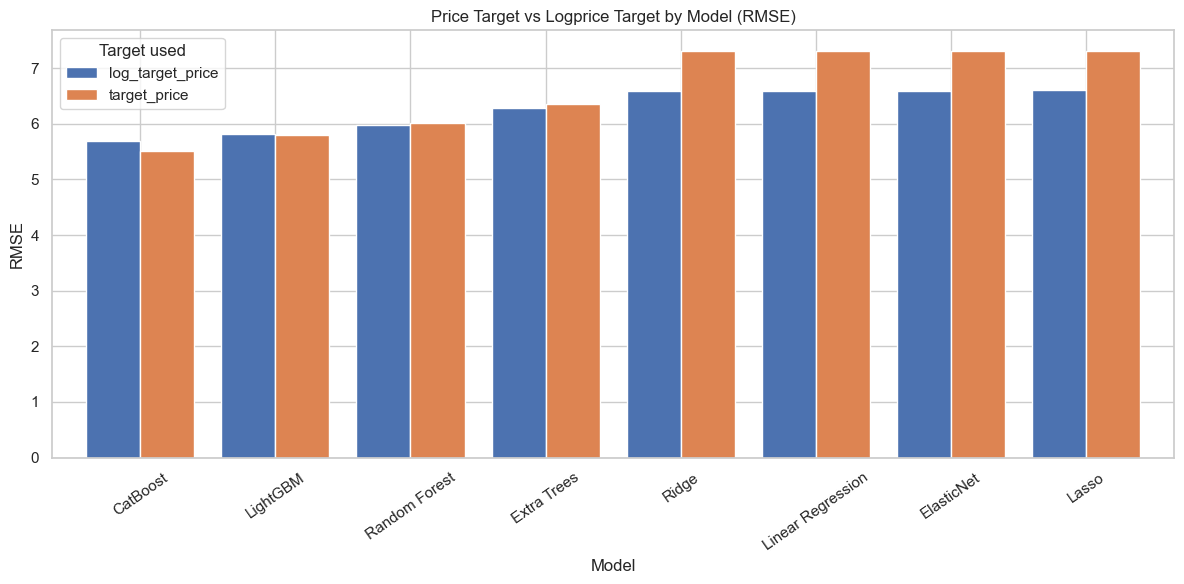

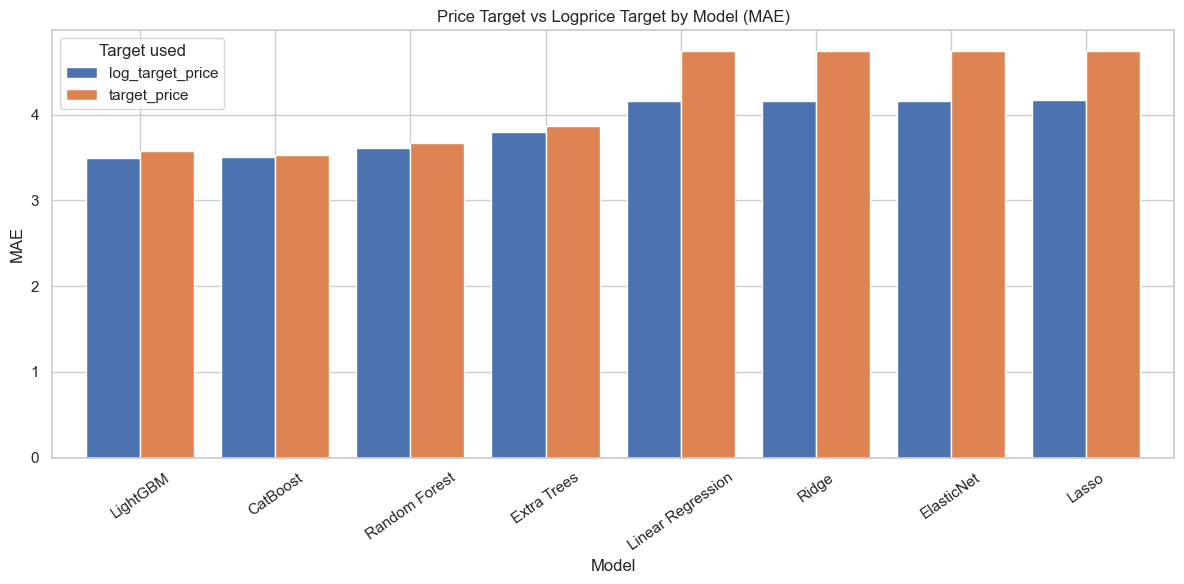

In [15]:
for metric in ['mae', 'rmse', 'r2']:
    plot_metric_comparison(metrics_df, metric)

plot_target_comparison(metrics_df, metric_name='rmse')
plot_target_comparison(metrics_df, metric_name='mae')

## Target Strategy Comparison

Các biểu đồ trên so sánh hiệu năng của từng mô hình khi train trực tiếp trên `target_price` và khi train trên `log_target_price`. Với các mô hình dùng `log_target_price`, prediction đã được chuyển ngược về thang giá thật trước khi tính MAE, RMSE và R². Vì vậy, các kết quả trong các biểu đồ này có thể được so sánh trực tiếp trên cùng một đơn vị là triệu VND.

Nhìn chung, nhóm mô hình tree-based ensemble vẫn cho kết quả tốt hơn nhóm linear models. `CatBoost` và `LightGBM` là hai mô hình có hiệu năng tốt nhất, với MAE và RMSE thấp nhất, đồng thời giữ R² cao nhất. Điều này tiếp tục cho thấy các mô hình gradient boosting phù hợp với bài toán dự đoán giá laptop hơn so với các mô hình tuyến tính đơn giản.

### MAE Comparison

Biểu đồ MAE cho thấy `log_target_price` thường giúp giảm sai số trung bình tuyệt đối ở hầu hết các mô hình. Sự cải thiện này thể hiện rõ nhất ở nhóm linear models như `Ridge`, `ElasticNet`, `Lasso` và `Linear Regression`. Với nhóm này, MAE khi dùng `log_target_price` thấp hơn đáng kể so với khi train trực tiếp trên `target_price`.

Ở nhóm tree-based models, chênh lệch giữa hai target nhỏ hơn. `CatBoost`, `LightGBM`, `Random Forest` và `Extra Trees` đều có MAE khá gần nhau giữa hai cách train. Tuy nhiên, `log_target_price` vẫn thường nhỉnh hơn nhẹ về MAE. Điều này cho thấy log-transform giúp giảm lỗi trung bình cho phần lớn observation, đặc biệt khi dữ liệu giá có phân phối lệch phải.

### RMSE Comparison

Biểu đồ RMSE cho thấy kết quả có sự khác biệt rõ hơn giữa các nhóm mô hình. Với `CatBoost`, bản train trực tiếp trên `target_price` có RMSE thấp hơn bản `log_target_price`. Điều này cho thấy mặc dù `log_target_price` giúp giảm MAE nhẹ, nó không nhất thiết giảm các lỗi lớn. Vì RMSE nhạy với outlier hơn MAE, một số dự đoán sai lớn có thể làm RMSE của bản log target cao hơn.

Với `LightGBM`, `Random Forest` và `Extra Trees`, sự khác biệt giữa hai target tương đối nhỏ. Trong một số trường hợp, `log_target_price` giúp RMSE tốt hơn nhẹ, nhưng không tạo ra khoảng cách quá lớn.

Ngược lại, ở nhóm linear models, `log_target_price` giúp giảm RMSE rất rõ so với `target_price`. Điều này cho thấy sau khi scale giá về triệu và tính lại log target, các mô hình tuyến tính đã ổn định hơn nhiều khi học trên target đã log-transform.

### R² Comparison

Biểu đồ R² cho thấy các mô hình tree-based ensemble vẫn giữ khả năng giải thích biến động giá tốt nhất. `CatBoost` đạt R² cao nhất, tiếp theo là `LightGBM`, `Random Forest` và `Extra Trees`.

Với nhóm linear models, `log_target_price` cho R² cao hơn rõ rệt so với `target_price`. Đây là điểm khác biệt quan trọng so với kết quả trước khi scale target, khi một số linear models có thể bị R² âm sau khi inverse từ log về giá thật. Kết quả hiện tại cho thấy việc chuyển giá sang đơn vị triệu và tính lại log target đã giúp nhóm linear models hoạt động ổn định hơn.

Tuy nhiên, dù linear models cải thiện đáng kể khi dùng `log_target_price`, R² của chúng vẫn thấp hơn nhóm tree-based models. Điều này cho thấy quan hệ giữa đặc trưng laptop và giá bán không hoàn toàn tuyến tính.

### Price Target vs Log Target

Hai biểu đồ cuối so sánh trực tiếp `target_price` và `log_target_price` theo RMSE và MAE cho từng mô hình.

Về MAE, `log_target_price` thường tốt hơn hoặc tương đương `target_price`. Điều này cho thấy log-transform giúp mô hình giảm sai số trung bình cho đa số mẫu. Đây là một lợi thế quan trọng nếu mục tiêu là dự đoán ổn định trên nhiều phân khúc giá khác nhau.

Về RMSE, kết quả phụ thuộc vào từng mô hình. `CatBoost` train trực tiếp trên `target_price` vẫn là lựa chọn tốt nhất nếu ưu tiên giảm lỗi lớn và tối ưu RMSE. Trong khi đó, `log_target_price` lại có lợi hơn với nhóm linear models và một số tree ensemble khác.

Nói cách khác, `log_target_price` không phải lúc nào cũng thắng tuyệt đối, nhưng nó giúp mô hình ổn định hơn ở metric MAE và cải thiện rõ rệt nhóm linear models.

### Key Takeaways

`CatBoost` vẫn là mô hình mạnh nhất và ổn định nhất trong toàn bộ nhóm mô hình đã thử. Nếu ưu tiên RMSE và R² trên thang giá thật, `CatBoost` train trực tiếp trên `target_price` là lựa chọn baseline chính.

`CatBoost` train trên `log_target_price` vẫn rất đáng giữ lại vì MAE thấp hơn nhẹ. Phiên bản này có thể phù hợp nếu mục tiêu là giảm sai số trung bình cho phần lớn laptop thay vì chỉ tối ưu các lỗi lớn.

`LightGBM` là ứng viên mạnh thứ hai, với hiệu năng gần `CatBoost` và thời gian train nhanh. Đây là mô hình nên được đưa vào bước hyperparameter tuning tiếp theo.

Nhóm linear models cải thiện rõ rệt khi dùng `log_target_price`, nhưng vẫn thấp hơn tree-based ensemble. Do đó, các mô hình này phù hợp làm baseline tham khảo hoặc phục vụ giải thích xu hướng tổng quát, không nên được chọn làm model chính.

Tổng thể, chiến lược tiếp theo nên là giữ cả hai hướng `target_price` và `log_target_price` cho `CatBoost` và `LightGBM`, sau đó tiếp tục so sánh bằng cross-validation, residual analysis và phân tích lỗi theo từng phân khúc giá, brand, condition và GPU type.

## 16. Generate actual vs predicted plots for top 3 models

Scatter plot Actual vs Predicted cho top 3 model giúp kiểm tra trực quan mức độ bám sát đường lý tưởng `y = x`. Nếu điểm lệch mạnh ở vùng giá cao hoặc giá thấp, đó là dấu hiệu nên phân tích thêm theo phân khúc laptop thay vì chỉ nhìn metric tổng thể.

,model_name,target_used,rmse,mae,r2
0,CatBoost,target_price,5.5091,3.5232,0.8638
1,CatBoost,log_target_price,5.6898,3.5104,0.8548
2,LightGBM,target_price,5.7955,3.5802,0.8493


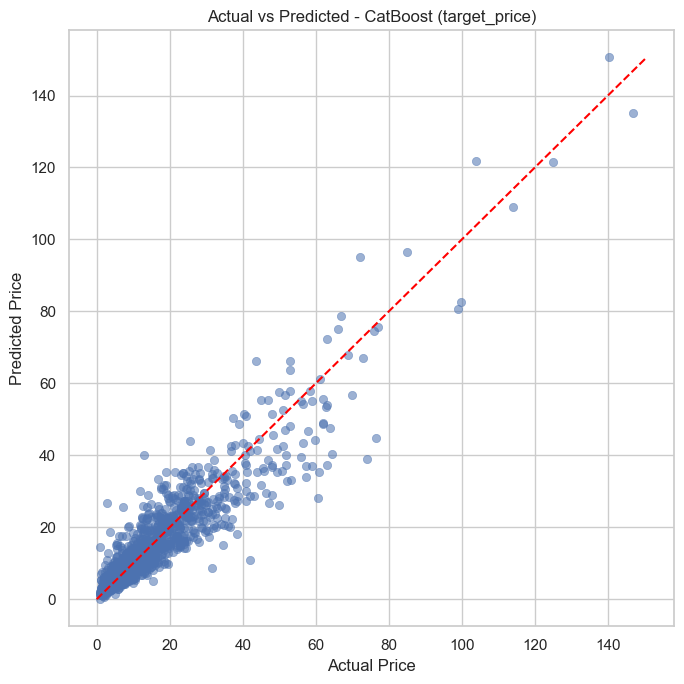

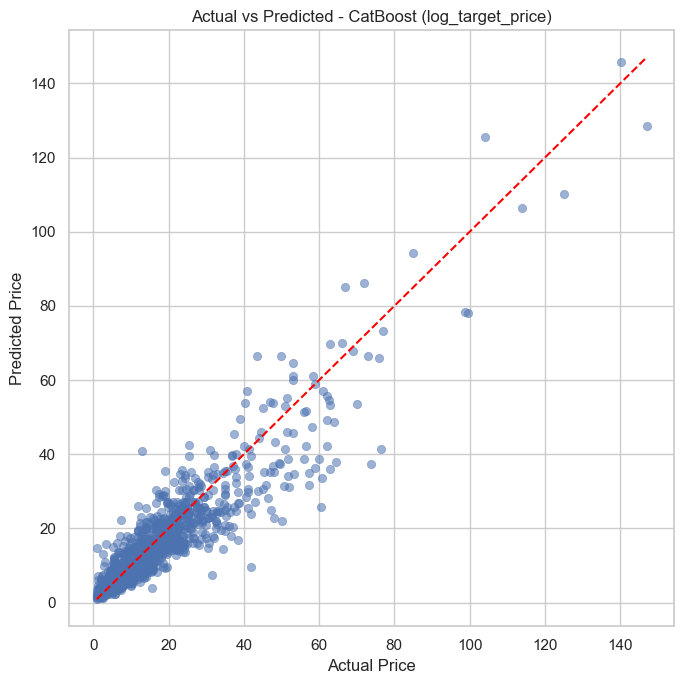

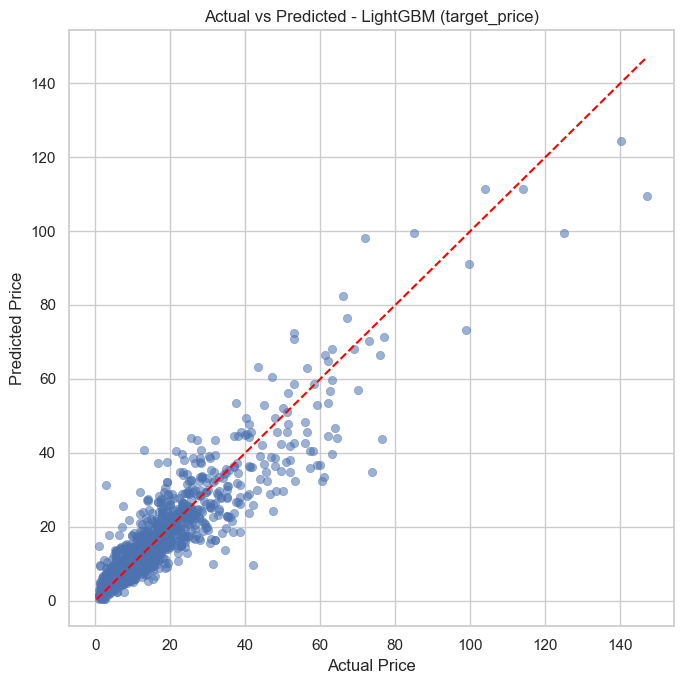

In [16]:
top_3_models = metrics_df.sort_values('rmse').head(3)[['model_name', 'target_used', 'rmse', 'mae', 'r2']]
display(top_3_models)

for _, row in top_3_models.iterrows():
    pred_col = f"pred_{safe_filename(row['model_name'], row['target_used'])}"
    plot_actual_vs_predicted(
        y_true=y_price_test,
        y_pred=predictions_df[pred_col].values,
        model_name=row['model_name'],
        target_used=row['target_used'],
    )

## Actual vs Predicted Analysis

Các biểu đồ `Actual vs Predicted` so sánh giá thật với giá dự đoán của các mô hình tốt nhất. Đường gạch đỏ biểu diễn đường dự đoán lý tưởng, tức là `predicted price = actual price`. Các điểm càng nằm gần đường này thì mô hình dự đoán càng chính xác. Vì `target_price` đã được scale về đơn vị triệu VND, cả trục `Actual Price` và `Predicted Price` đều được hiểu theo đơn vị triệu đồng.

Nhìn chung, cả ba mô hình đều học được xu hướng chính của dữ liệu. Phần lớn điểm dữ liệu tập trung quanh đường chéo, đặc biệt ở vùng giá thấp và trung bình. Điều này cho thấy các mô hình dự đoán tương đối tốt đối với nhóm laptop phổ biến trong tập test.

### CatBoost with `target_price`

Biểu đồ của `CatBoost` train trực tiếp trên `target_price` cho thấy các điểm phân bố khá sát đường lý tưởng. Mô hình dự đoán tốt ở vùng giá thấp đến trung bình, đặc biệt trong khoảng dưới 40 triệu. Đây cũng là vùng có mật độ dữ liệu cao nhất, nên mô hình học được pattern ổn định hơn.

Ở vùng giá cao, các điểm bắt đầu phân tán rộng hơn. Một số laptop có giá thực tế trên 80–140 triệu vẫn được dự đoán khá gần đường chéo, nhưng cũng có một số trường hợp bị underestimate hoặc overestimate đáng kể. Điều này cho thấy mô hình vẫn gặp khó khăn với các mẫu laptop cao cấp hoặc cấu hình hiếm.

Nhìn tổng thể, `CatBoost` với `target_price` là mô hình cân bằng tốt, đặc biệt nếu mục tiêu là tối ưu RMSE và R² trên thang giá thật.

### CatBoost with `log_target_price`

Biểu đồ của `CatBoost` train trên `log_target_price` có pattern khá giống với bản train trực tiếp trên `target_price`. Các điểm vẫn tập trung tốt quanh đường chéo ở vùng giá thấp và trung bình. Điều này cho thấy việc log-transform target không làm mất đi khả năng học xu hướng chính của giá laptop.

So với bản `target_price`, mô hình `log_target_price` có xu hướng ổn định ở vùng giá phổ biến, nhưng vẫn xuất hiện sai số lớn ở một số điểm giá cao. Một số mẫu giá cao bị dự đoán thấp hơn giá thật, trong khi một số mẫu khác lại được dự đoán cao hơn. Đây là lý do vì sao bản `log_target_price` có thể có MAE tốt hơn nhẹ, nhưng RMSE chưa chắc tốt hơn bản `target_price`.

Nhìn chung, `CatBoost` với `log_target_price` vẫn là một lựa chọn rất cạnh tranh, đặc biệt nếu ưu tiên giảm sai số trung bình cho phần lớn laptop.

### LightGBM with `target_price`

Biểu đồ của `LightGBM` train trực tiếp trên `target_price` cũng cho thấy mô hình học được quan hệ giữa feature và giá khá tốt. Các điểm ở vùng giá thấp và trung bình bám tương đối sát đường chéo, tương tự `CatBoost`.

Tuy nhiên, ở vùng giá cao, `LightGBM` có một số điểm phân tán rõ hơn. Một vài laptop thực tế có giá rất cao nhưng bị dự đoán thấp hơn đáng kể. Điều này cho thấy `LightGBM` có thể đang bảo thủ hơn ở vùng giá cao, hoặc chưa học đủ tốt các pattern đặc biệt của nhóm laptop premium/workstation.

Dù vậy, hiệu năng tổng thể của `LightGBM` vẫn rất tốt và gần với `CatBoost`, nên đây là một ứng viên mạnh cho bước tuning tiếp theo.

### Error Pattern

Các điểm nằm phía trên đường đỏ là những mẫu bị mô hình dự đoán cao hơn giá thật. Ngược lại, các điểm nằm phía dưới đường đỏ là những mẫu bị dự đoán thấp hơn giá thật.

Pattern chung của cả ba biểu đồ là sai số tăng dần khi giá thực tế tăng. Đây là hiện tượng khá phổ biến trong bài toán dự đoán giá, vì nhóm laptop giá cao thường ít mẫu hơn, có cấu hình đặc biệt hơn, và bị ảnh hưởng bởi các yếu tố khó biểu diễn đầy đủ trong feature như dòng máy cao cấp, độ mới, thiết kế, màn hình, GPU workstation, hoặc tình trạng thực tế của sản phẩm.

Vùng giá thấp và trung bình có mật độ dữ liệu lớn hơn nên mô hình dự đoán ổn định hơn. Ngược lại, vùng giá cao có ít điểm dữ liệu hơn nên độ phân tán lớn hơn.

### Key Takeaways

Các biểu đồ xác nhận rằng `CatBoost` và `LightGBM` đều là các baseline mạnh cho bài toán dự đoán giá laptop. Cả hai mô hình đều dự đoán tốt trên phần lớn khoảng giá phổ biến.

`CatBoost` train trực tiếp trên `target_price` có vẻ là lựa chọn tốt nhất nếu ưu tiên RMSE và R², vì các điểm nhìn chung bám sát đường lý tưởng và ít bị lệch lớn hơn ở một số vùng giá cao.

`CatBoost` train trên `log_target_price` vẫn rất đáng giữ lại vì có khả năng giảm MAE nhẹ và dự đoán ổn định ở vùng giá phổ biến.

`LightGBM` có performance gần với `CatBoost`, nhưng cần kiểm tra thêm các mẫu bị underestimate ở vùng giá cao.

Bước tiếp theo nên là thực hiện residual analysis, đặc biệt tập trung vào các mẫu có lỗi lớn nhất. Nên kiểm tra các lỗi này theo price range, brand, model, GPU type, condition và warranty để xác định nguyên nhân sai số và cải thiện feature engineering hoặc tuning.

## 17. Generate residual and error distribution plots for top 3 models

Residual plot cho biết sai số có phân bố ngẫu nhiên hay bị lệch theo mức giá dự đoán. Error distribution plot giúp quan sát bias tổng thể: phân phối centered gần 0 là tốt, còn lệch hẳn sang một phía cho thấy model có xu hướng overestimate hoặc underestimate.

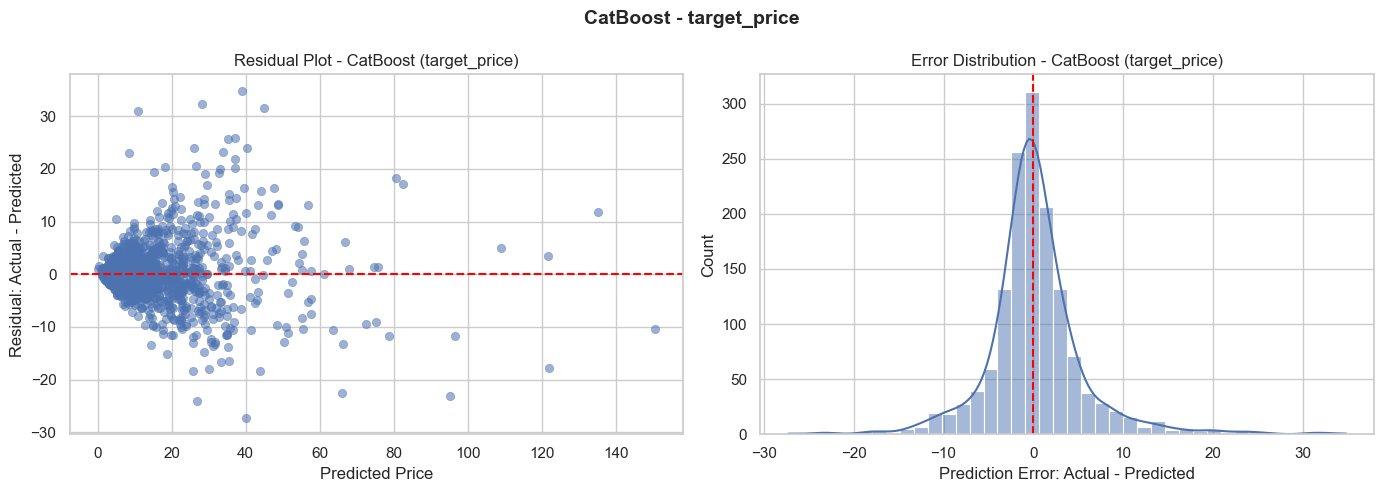

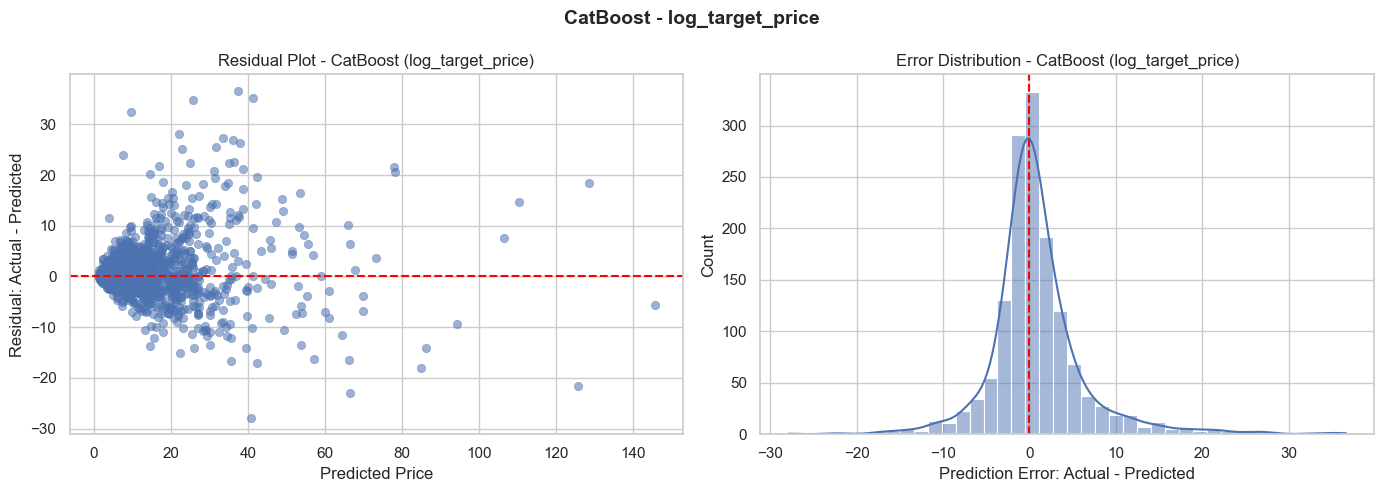

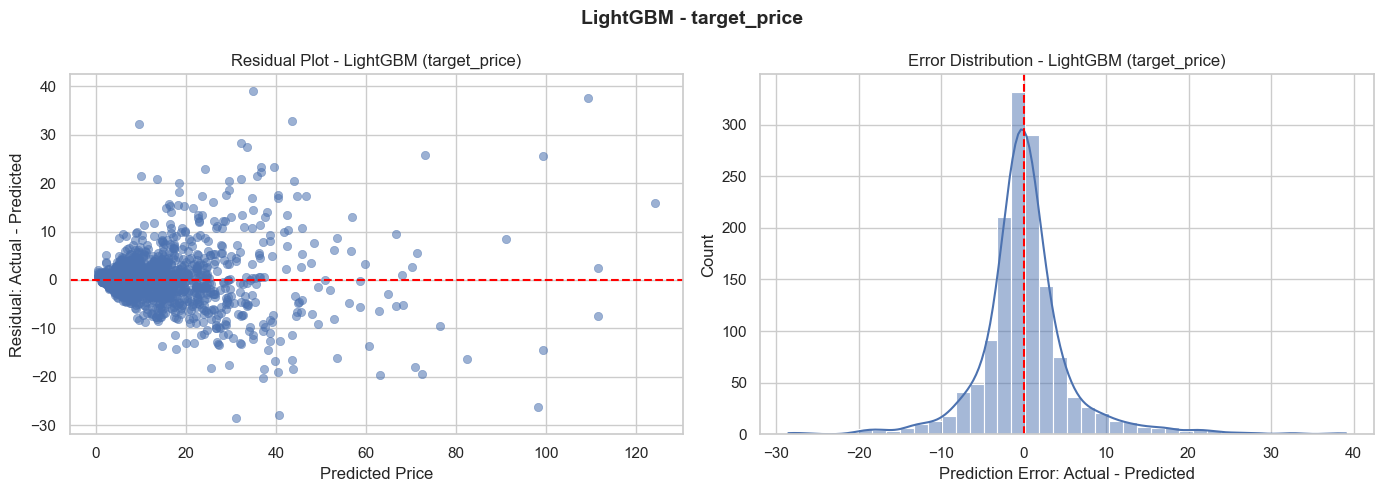

In [17]:
for _, row in top_3_models.iterrows():
    pred_col = f"pred_{safe_filename(row['model_name'], row['target_used'])}"
    y_pred_current = predictions_df[pred_col].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_residuals(
        y_true=y_price_test,
        y_pred=y_pred_current,
        model_name=row['model_name'],
        target_used=row['target_used'],
        ax=axes[0]
    )

    plot_error_distribution(
        y_true=y_price_test,
        y_pred=y_pred_current,
        model_name=row['model_name'],
        target_used=row['target_used'],
        ax=axes[1]
    )

    fig.suptitle(
        f"{row['model_name']} - {row['target_used']}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

## 18. Save feature importance / coefficients

Với tree-based model, notebook lưu `feature_importances_`; với linear model, notebook lưu coefficient table. Cột `abs_importance` hỗ trợ sắp xếp độ ảnh hưởng tuyệt đối, nhưng khi diễn giải linear coefficient vẫn nên chú ý dấu âm/dương của cột `importance`.

In [18]:
feature_importance_frames = []

for model_key, fitted_model in trained_models.items():
    model_name, target_used = model_key.rsplit('_', 1)
    importance_df = extract_feature_importance(fitted_model, model_name, feature_names)

    if importance_df is None:
        print(f'No feature importance or coefficients available for {model_key}.')
        continue

    importance_df['target_used'] = target_used
    output_columns = ['feature', 'importance', 'model_name', 'target_used', 'importance_type', 'abs_importance']
    importance_df = importance_df[output_columns]

    output_path = FEATURE_IMPORTANCE_DIR / f'{safe_filename(model_name, target_used)}_feature_importance.csv'
    importance_df.to_csv(output_path, index=False)
    feature_importance_frames.append(importance_df)
    print(f'Saved: {output_path.name}')

if feature_importance_frames:
    all_feature_importance_df = pd.concat(feature_importance_frames, ignore_index=True)
    all_feature_importance_path = FEATURE_IMPORTANCE_DIR / 'all_feature_importance.csv'
    all_feature_importance_df.to_csv(all_feature_importance_path, index=False)
    display(all_feature_importance_df.head(20))
else:
    all_feature_importance_df = pd.DataFrame()

Saved: LinearRegression_target_price_feature_importance.csv
Saved: LinearRegression_log_target_price_feature_importance.csv
Saved: Ridge_target_price_feature_importance.csv
Saved: Ridge_log_target_price_feature_importance.csv
Saved: Lasso_target_price_feature_importance.csv
Saved: Lasso_log_target_price_feature_importance.csv
Saved: ElasticNet_target_price_feature_importance.csv
Saved: ElasticNet_log_target_price_feature_importance.csv
Saved: RandomForest_target_price_feature_importance.csv
Saved: RandomForest_log_target_price_feature_importance.csv
Saved: ExtraTrees_target_price_feature_importance.csv
Saved: ExtraTrees_log_target_price_feature_importance.csv
Saved: LightGBM_target_price_feature_importance.csv
Saved: LightGBM_log_target_price_feature_importance.csv
Saved: CatBoost_target_price_feature_importance.csv
Saved: CatBoost_log_target_price_feature_importance.csv


,feature,importance,model_name,target_used,importance_type,abs_importance
0,gpu_type_Integrated,"91,787,352,527,806.7500",Linear Regression_target,price,coefficient,"91,787,352,527,806.7500"
1,gpu_type_Dedicated,"79,219,302,252,027.3906",Linear Regression_target,price,coefficient,"79,219,302,252,027.3906"
2,gpu_type_Missing_Info,"78,794,193,944,946.0156",Linear Regression_target,price,coefficient,"78,794,193,944,946.0156"
3,cpu_brand_Other,"31,798,568,291,882.6445",Linear Regression_target,price,coefficient,"31,798,568,291,882.6445"
4,cpu_brand_Intel,"29,055,203,998,524.0117",Linear Regression_target,price,coefficient,"29,055,203,998,524.0117"
5,no_info_model,"-23,599,652,294,896.7695",Linear Regression_target,price,coefficient,"23,599,652,294,896.7695"
6,model_is_rare,"-22,552,975,538,188.7617",Linear Regression_target,price,coefficient,"22,552,975,538,188.7617"
7,gpu_type_Apple SoC,"22,277,153,630,368.1484",Linear Regression_target,price,coefficient,"22,277,153,630,368.1484"
8,cpu_brand_AMD,"21,709,900,391,138.9531",Linear Regression_target,price,coefficient,"21,709,900,391,138.9531"
9,no_info_cpu_brand,"-18,237,163,624,883.5586",Linear Regression_target,price,coefficient,"18,237,163,624,883.5586"


## 19. Summary of best models

Phần cuối notebook tổng hợp top model theo RMSE và MAE, so sánh `price` với `logprice` trong từng thuật toán, rồi in kết luận tự động. Kết luận có kiểm tra khoảng cách giữa các model top đầu; nếu chênh lệch nhỏ, notebook sẽ ghi rõ rằng kết quả nên được xem là sát nhau thay vì khẳng định tuyệt đối.

In [19]:
top_by_rmse = metrics_df.sort_values('rmse').head(10).reset_index(drop=True)
top_by_mae = metrics_df.sort_values('mae').head(10).reset_index(drop=True)

display(top_by_rmse)
display(top_by_mae)

# Compare price vs logprice target for each model.
target_comparison_rows = []
for model_name, group in metrics_df.groupby('model_name'):
    pivot = group.set_index('target_used')
    if {'target_price', 'log_target_price'}.issubset(pivot.index):
        price_rmse = pivot.loc['target_price', 'rmse']
        log_rmse = pivot.loc['log_target_price', 'rmse']
        price_mae = pivot.loc['target_price', 'mae']
        log_mae = pivot.loc['log_target_price', 'mae']
        target_comparison_rows.append(
            {
                'model_name': model_name,
                'price_rmse': price_rmse,
                'logprice_rmse': log_rmse,
                'rmse_winner': 'log_target_price' if log_rmse < price_rmse else 'target_price',
                'rmse_pct_diff_log_vs_price': (log_rmse - price_rmse) / price_rmse,
                'price_mae': price_mae,
                'logprice_mae': log_mae,
                'mae_winner': 'log_target_price' if log_mae < price_mae else 'target_price',
                'mae_pct_diff_log_vs_price': (log_mae - price_mae) / price_mae,
            }
        )

target_comparison_df = pd.DataFrame(target_comparison_rows).sort_values('model_name')
display(target_comparison_df)

best_rmse_row = metrics_df.loc[metrics_df['rmse'].idxmin()]
best_mae_row = metrics_df.loc[metrics_df['mae'].idxmin()]

target_summary = metrics_df.groupby('target_used')[['rmse', 'mae', 'r2']].mean().sort_values('rmse')
best_target_overall = target_summary.index[0]

rmse_gap = (
    metrics_df.sort_values('rmse').iloc[1]['rmse'] - best_rmse_row['rmse']
) / best_rmse_row['rmse'] if len(metrics_df) > 1 else np.nan

mae_gap = (
    metrics_df.sort_values('mae').iloc[1]['mae'] - best_mae_row['mae']
) / best_mae_row['mae'] if len(metrics_df) > 1 else np.nan

print('Automatic conclusion')
print('--------------------')
print(
    f"Best model by RMSE: {best_rmse_row['model_name']} trained on {best_rmse_row['target_used']} "
    f"with RMSE={best_rmse_row['rmse']:,.4f}, MAE={best_rmse_row['mae']:,.4f}, R2={best_rmse_row['r2']:,.4f}."
)
print(
    f"Best model by MAE : {best_mae_row['model_name']} trained on {best_mae_row['target_used']} "
    f"with MAE={best_mae_row['mae']:,.4f}, RMSE={best_mae_row['rmse']:,.4f}, R2={best_mae_row['r2']:,.4f}."
)
print(f"Best target overall by average RMSE across models: {best_target_overall}.")

if not np.isnan(rmse_gap) and rmse_gap < 0.02:
    print('RMSE difference between the top two variants is below 2%, so the winner should be treated as a close result.')
if not np.isnan(mae_gap) and mae_gap < 0.02:
    print('MAE difference between the top two variants is below 2%, so the winner should be treated as a close result.')

if best_target_overall == 'log_target_price':
    print('Recommendation: logprice is currently preferable on average, but confirm with residual plots and business tolerance for large-price errors.')
else:
    print('Recommendation: direct price modeling is currently preferable on average, but confirm with residual plots and segment-level errors.')

,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,CatBoost,gradient_boosting,target_price,target_price,3.5232,5.5091,0.8638,0.3338,2.1233,34.8488,6.7037,0.0034
1,CatBoost,gradient_boosting,log_target_price,target_price,3.5104,5.6898,0.8548,0.2976,2.0116,36.6086,2.7241,0.0057
2,LightGBM,gradient_boosting,target_price,target_price,3.5802,5.7955,0.8493,0.3312,2.0342,39.1037,1.2007,0.0139
3,LightGBM,gradient_boosting,log_target_price,target_price,3.4950,5.8081,0.8487,0.2963,1.8476,42.3846,1.6195,0.0182
4,Random Forest,tree_ensemble,log_target_price,target_price,3.6066,5.9864,0.8392,0.3113,1.9254,36.6135,1.8349,0.1616
5,Random Forest,tree_ensemble,target_price,target_price,3.6688,6.0052,0.8382,0.3381,1.9738,38.3213,1.7116,0.1582
6,Extra Trees,tree_ensemble,log_target_price,target_price,3.7978,6.2890,0.8226,0.3309,2.1057,45.0000,2.0182,0.1581
7,Extra Trees,tree_ensemble,target_price,target_price,3.8622,6.3532,0.8189,0.3547,2.1455,45.0000,2.1629,0.1810
8,Ridge,linear,log_target_price,target_price,4.1590,6.5850,0.8055,0.3571,2.4797,48.5077,0.0446,0.0066
9,Linear Regression,linear,log_target_price,target_price,4.1561,6.5929,0.8050,0.3565,2.4827,47.6699,0.3739,0.0031


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,LightGBM,gradient_boosting,log_target_price,target_price,3.4950,5.8081,0.8487,0.2963,1.8476,42.3846,1.6195,0.0182
1,CatBoost,gradient_boosting,log_target_price,target_price,3.5104,5.6898,0.8548,0.2976,2.0116,36.6086,2.7241,0.0057
2,CatBoost,gradient_boosting,target_price,target_price,3.5232,5.5091,0.8638,0.3338,2.1233,34.8488,6.7037,0.0034
3,LightGBM,gradient_boosting,target_price,target_price,3.5802,5.7955,0.8493,0.3312,2.0342,39.1037,1.2007,0.0139
4,Random Forest,tree_ensemble,log_target_price,target_price,3.6066,5.9864,0.8392,0.3113,1.9254,36.6135,1.8349,0.1616
5,Random Forest,tree_ensemble,target_price,target_price,3.6688,6.0052,0.8382,0.3381,1.9738,38.3213,1.7116,0.1582
6,Extra Trees,tree_ensemble,log_target_price,target_price,3.7978,6.2890,0.8226,0.3309,2.1057,45.0000,2.0182,0.1581
7,Extra Trees,tree_ensemble,target_price,target_price,3.8622,6.3532,0.8189,0.3547,2.1455,45.0000,2.1629,0.1810
8,Linear Regression,linear,log_target_price,target_price,4.1561,6.5929,0.8050,0.3565,2.4827,47.6699,0.3739,0.0031
9,Ridge,linear,log_target_price,target_price,4.1590,6.5850,0.8055,0.3571,2.4797,48.5077,0.0446,0.0066


,model_name,price_rmse,logprice_rmse,rmse_winner,rmse_pct_diff_log_vs_price,price_mae,logprice_mae,mae_winner,mae_pct_diff_log_vs_price
0,CatBoost,5.5091,5.6898,target_price,0.0328,3.5232,3.5104,log_target_price,-0.0036
1,ElasticNet,7.3105,6.5975,log_target_price,-0.0975,4.7401,4.1614,log_target_price,-0.1221
2,Extra Trees,6.3532,6.2890,log_target_price,-0.0101,3.8622,3.7978,log_target_price,-0.0167
3,Lasso,7.3108,6.6122,log_target_price,-0.0956,4.7399,4.1681,log_target_price,-0.1206
4,LightGBM,5.7955,5.8081,target_price,0.0022,3.5802,3.4950,log_target_price,-0.0238
5,Linear Regression,7.3123,6.5929,log_target_price,-0.0984,4.7451,4.1561,log_target_price,-0.1241
6,Random Forest,6.0052,5.9864,log_target_price,-0.0031,3.6688,3.6066,log_target_price,-0.0170
7,Ridge,7.3102,6.5850,log_target_price,-0.0992,4.7404,4.1590,log_target_price,-0.1226


Automatic conclusion
--------------------
Best model by RMSE: CatBoost trained on target_price with RMSE=5.5091, MAE=3.5232, R2=0.8638.
Best model by MAE : LightGBM trained on log_target_price with MAE=3.4950, RMSE=5.8081, R2=0.8487.
Best target overall by average RMSE across models: log_target_price.
MAE difference between the top two variants is below 2%, so the winner should be treated as a close result.
Recommendation: logprice is currently preferable on average, but confirm with residual plots and business tolerance for large-price errors.
